В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [6]:
print('\nТипи колонок:')
cars_df.dtypes


Типи колонок:


,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [7]:
cars_df.isnull().values.any()

np.False_

In [8]:
cars_df.select_dtypes(include='object').nunique()

,0
Brand,11
Model,58
Fuel_Type,2
Transmission,2
Owner_Type,3


In [13]:
cars_df.select_dtypes(include='int64').nunique()

,0
Car_ID,100
Year,6
Kilometers_Driven,18
Mileage,15
Engine,36
Power,40
Seats,3
Price,31


### Висновок

В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення): Fuel_Type та Transmission
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку: Brand та Model
- 1 колонка, в яких можна встановити відношення порядку: Owner_Type

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [15]:
X = cars_df.drop(columns=['Price', 'Car_ID'])
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (80, 11)
X_test: (20, 11)
y_train: (80,)
y_test: (20,)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

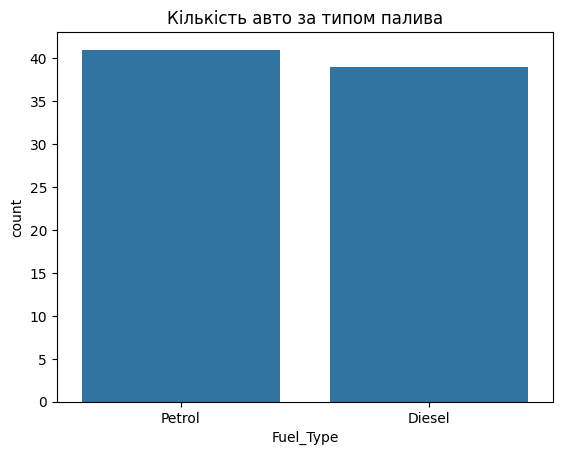

In [16]:
sns.countplot(data=X_train, x='Fuel_Type')
plt.title('Кількість авто за типом палива')
plt.show()

In [17]:
fuel_codes = {'Petrol': 1, 'Diesel': 0}
X_train['fuel_code'] = X_train['Fuel_Type'].map(fuel_codes)
X_test['fuel_code'] = X_test['Fuel_Type'].map(fuel_codes)

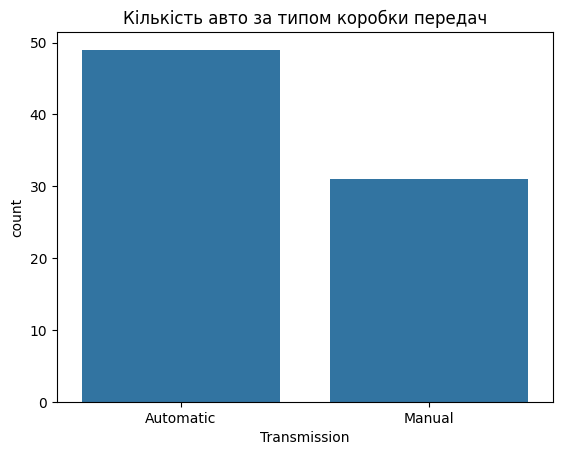

In [18]:
sns.countplot(data=X_train, x='Transmission')
plt.title('Кількість авто за типом коробки передач')
plt.show()

In [19]:
transmission_codes = {'Automatic' : 1, 'Manual' : 0}
X_train['transmission_code'] = X_train['Transmission'].map(transmission_codes)
X_test['transmission_code'] = X_test['Transmission'].map(transmission_codes)

In [22]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [23]:
X_train_encoded = enc.transform(X_train[['Brand']]).toarray()
X_test_encoded = enc.transform(X_test[['Brand']]).toarray()

In [24]:
X_train[enc.categories_[0]] = X_train_encoded
X_test[enc.categories_[0]] = X_test_encoded

In [25]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [26]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

In [30]:
# Рахуємо середню ціну для кожної моделі тільки на train
model_avg_price = X_train.join(y_train).groupby('Model')['Price'].mean()

# Ділимо моделі на 4 цінові категорії
price_bins = [0, 1_000_000, 2_000_000, 3_000_000, float('inf')]
price_labels = ['Low', 'Mid', 'High', 'Luxury']

model_price_category = pd.cut(
    model_avg_price,
    bins=price_bins,
    labels=price_labels
)

# Додаємо категорію моделі у train і test
X_train['Model_Category'] = X_train['Model'].map(model_price_category)
X_test['Model_Category'] = X_test['Model'].map(model_price_category)

# Моделі, яких не було у train, позначаємо як Unknown
X_test['Model_Category'] = (
    X_test['Model_Category']
    .cat.add_categories('Unknown')
    .fillna('Unknown')
)

print('Кількість моделей у кожній категорії:')
print(X_train['Model_Category'].value_counts())

display(X_train[['Model', 'Model_Category']].head(10))
display(X_test[['Model', 'Model_Category']].head(10))

Кількість моделей у кожній категорії:
Model_Category
Low       35
High      21
Mid       16
Luxury     8
Name: count, dtype: int64


,Model,Model_Category
83,T-Roc,Mid
55,A5,High
26,A6,Luxury
54,Vento,Low
19,GLC,High
57,C-Class,High
46,Q7,High
23,Altroz,Low
36,A3,Mid
91,XUV300,Low


,Model,Model_Category
17,Q3,Unknown
41,Santro,Low
92,Vento,Low
14,Ertiga,Unknown
68,Aspire,Low
31,Elantra,Low
89,Venue,Low
15,City,Unknown
21,Figo,Unknown
60,Verna,Low


In [28]:
model_category_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

model_category_encoder.fit(X_train[['Model_Category']])

model_train_encoded = model_category_encoder.transform(
    X_train[['Model_Category']]
)

model_test_encoded = model_category_encoder.transform(
    X_test[['Model_Category']]
)

model_train_df = pd.DataFrame(
    model_train_encoded,
    columns=model_category_encoder.get_feature_names_out(['Model_Category']),
    index=X_train.index
)

model_test_df = pd.DataFrame(
    model_test_encoded,
    columns=model_category_encoder.get_feature_names_out(['Model_Category']),
    index=X_test.index
)

X_train = pd.concat([X_train, model_train_df], axis=1)
X_test = pd.concat([X_test, model_test_df], axis=1)

print('Нові колонки:')
print(model_category_encoder.get_feature_names_out(['Model_Category']))

display(X_train.head())

Нові колонки:
['Model_Category_High' 'Model_Category_Low' 'Model_Category_Luxury'
 'Model_Category_Mid']


,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Category,Model_Category_High,Model_Category_Low,Model_Category_Luxury,Model_Category_Mid
83,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Mid,0.0,0.0,0.0,1.0
55,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,High,1.0,0.0,0.0,0.0
26,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Luxury,0.0,0.0,1.0,0.0
54,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Low,0.0,1.0,0.0,0.0
19,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,High,1.0,0.0,0.0,0.0


**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [31]:
# Залишаємо лише числові ознаки
X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

# Додаємо цільову змінну Price
train_numeric_df = pd.concat([X_train_numeric, y_train], axis=1)
test_numeric_df = pd.concat([X_test_numeric, y_test], axis=1)

print('Розмір train:', train_numeric_df.shape)
print('Розмір test:', test_numeric_df.shape)

display(train_numeric_df.head())

Розмір train: (80, 25)
Розмір test: (20, 25)


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Category_High,Model_Category_Low,Model_Category_Luxury,Model_Category_Mid,Price
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1600000
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2600000
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3200000
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,650000
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2500000


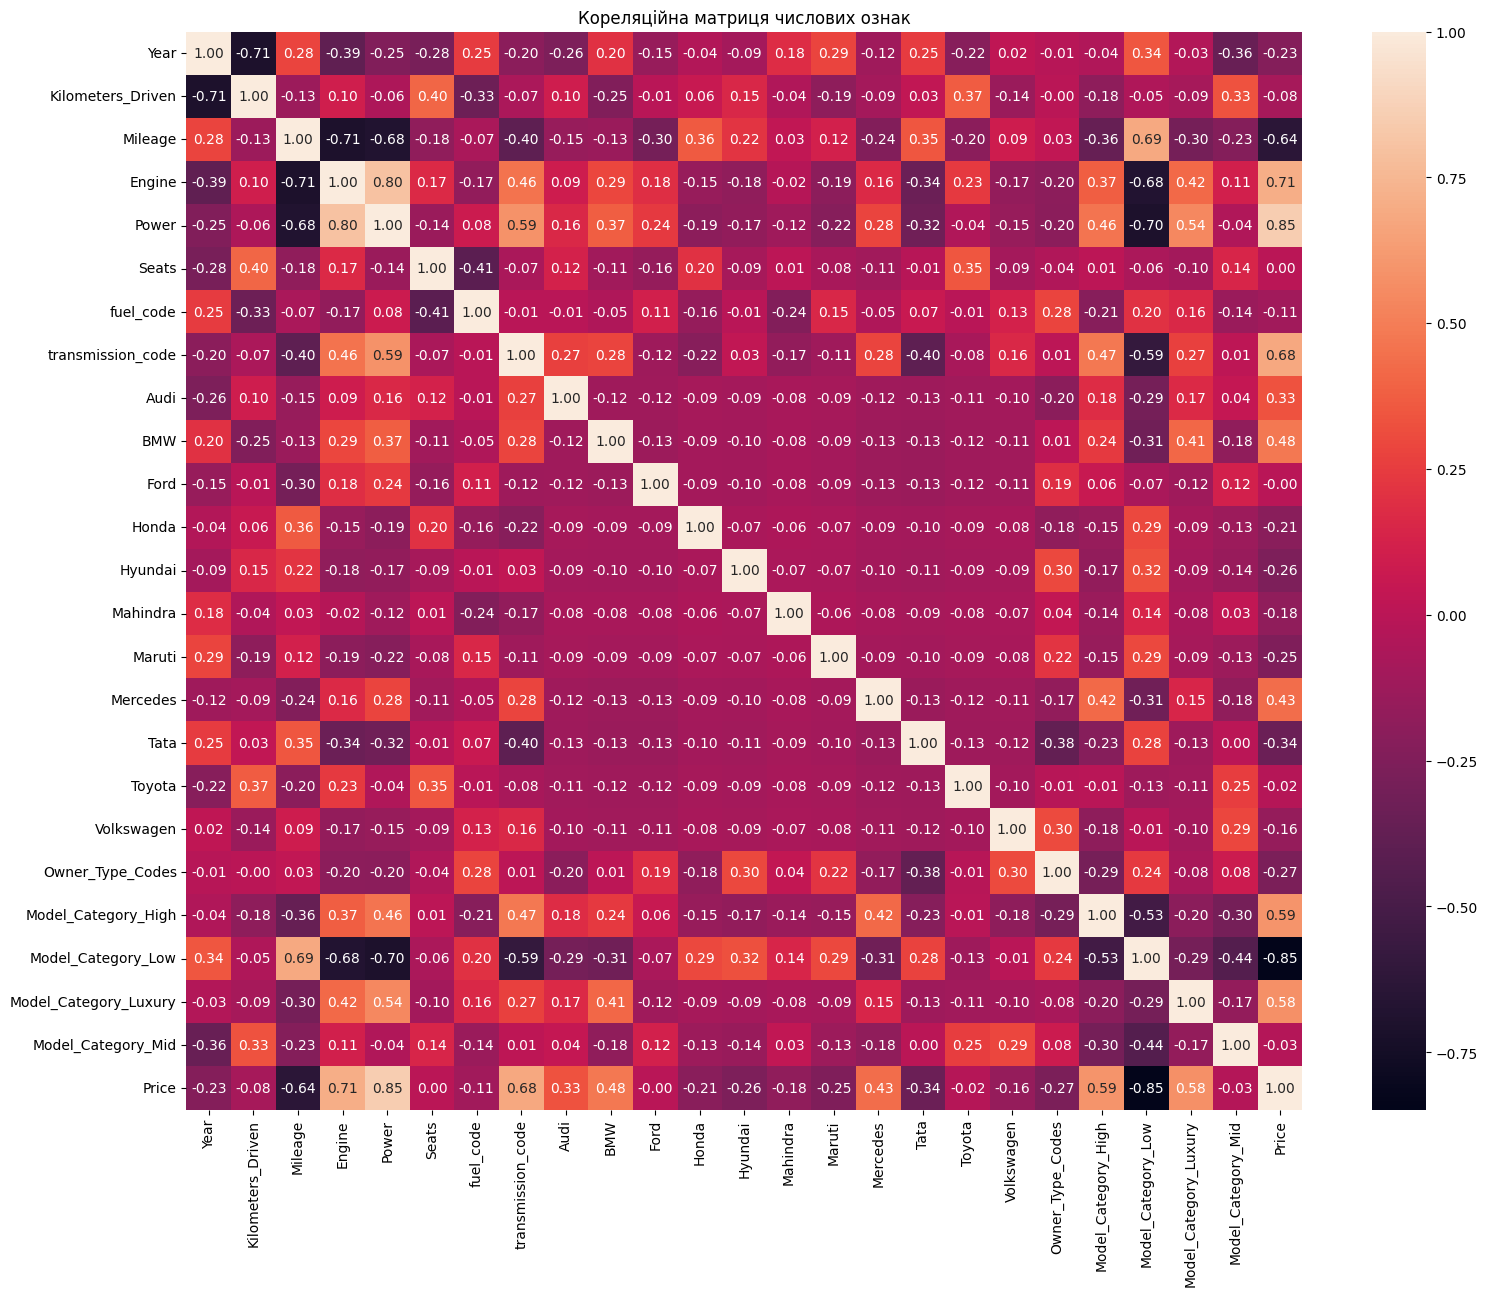

In [32]:
correlation_matrix = train_numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')
plt.title('Кореляційна матриця числових ознак')
plt.show()

In [33]:
price_correlations = correlation_matrix['Price'].sort_values(ascending=False)

print('Кореляція ознак із Price:')
print(price_correlations)

Кореляція ознак із Price:
Price                    1.000000
Power                    0.849137
Engine                   0.710561
transmission_code        0.680731
Model_Category_High      0.588590
Model_Category_Luxury    0.578725
BMW                      0.477522
Mercedes                 0.431606
Audi                     0.328858
Seats                    0.000979
Ford                    -0.004592
Toyota                  -0.023778
Model_Category_Mid      -0.029621
Kilometers_Driven       -0.083951
fuel_code               -0.110782
Volkswagen              -0.158742
Mahindra                -0.178627
Honda                   -0.209779
Year                    -0.233769
Maruti                  -0.249737
Hyundai                 -0.263022
Owner_Type_Codes        -0.265537
Tata                    -0.341815
Mileage                 -0.638404
Model_Category_Low      -0.848141
Name: Price, dtype: float64


### Висновок

За кореляційною матрицею найбільш позитивно з ціною автомобіля корелюють потужність двигуна (`Power`, 0.85), об’єм двигуна (`Engine`, 0.71) та тип коробки передач (`transmission_code`, 0.68). Найбільшу негативну кореляцію має пробіг (`Mileage`, -0.64): зі збільшенням пробігу ціна автомобіля переважно зменшується.

Також сильний зв’язок із ціною мають створені категорії моделей: `Model_Category_High` і `Model_Category_Luxury` мають позитивну кореляцію, а `Model_Category_Low` негативну. Це очікувано, оскільки ці категорії були сформовані на основі середньої ціни моделей.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [34]:
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

print('Розмір X_train:', X_train.shape)
print('Розмір X_test:', X_test.shape)

Розмір X_train: (80, 24)
Розмір X_test: (20, 24)


In [39]:
# Навчаємо модель
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнози
predictions_train = linear_model.predict(X_train)
predictions_test = linear_model.predict(X_test)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, predictions_train))
rmse_test = np.sqrt(mean_squared_error(y_test, predictions_test))

print('RMSE на train:', rmse_train)
print('RMSE на test:', rmse_test)

RMSE на train: 135895.36219976612
RMSE на test: 436330.9993681983


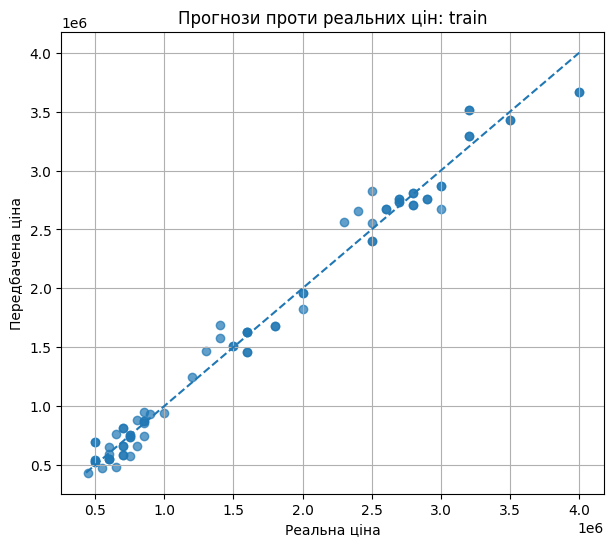

In [49]:
plt.figure(figsize=(7, 6))

plt.scatter(y_train, predictions_train, alpha=0.7)

line_min = min(y_train.min(), predictions_train.min())
line_max = max(y_train.max(), predictions_train.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')

plt.title('Прогнози проти реальних цін: train')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.grid(True)
plt.show()

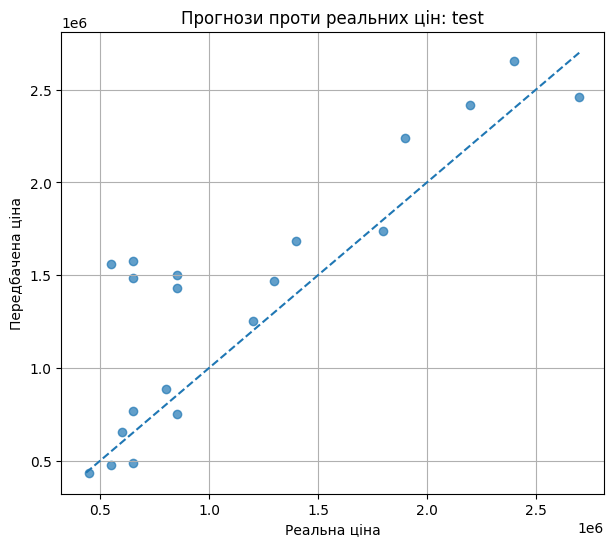

In [50]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, predictions_test, alpha=0.7)

line_min = min(y_test.min(), predictions_test.min())
line_max = max(y_test.max(), predictions_test.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')

plt.title('Прогнози проти реальних цін: test')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.grid(True)
plt.show()



### Висновок

На тренувальних даних модель добре передбачає цілову змінну, точки лежать досить близько до діагоналі, але це може бути ознакою того, що модель перенавчилась.

На тестових даних точки більш розкидані і лежать не так близько до діагоналі. Це може означати, що модель не навчилась добре узагальнювати дані, яких вона ще не бачила.

На тесті середня помилка приблизно 436 тисяч, а це в ~3 рази більше, ніж на train.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

coefficients = pd.Series(
    scaled_model.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

coefficients

,0
Model_Category_Low,-333571.908475
Model_Category_Luxury,309065.378996
Power,238172.226847
Model_Category_High,191064.209696
transmission_code,104183.984968
Mercedes,103167.885432
BMW,90554.187063
Audi,82437.130482
fuel_code,-72579.071051
Volkswagen,-70856.692208


In [57]:
predictions_train = scaled_model.predict(X_train_scaled)
predictions_test = scaled_model.predict(X_test_scaled)

rmse_train_scaled = np.sqrt(mean_squared_error(y_train, predictions_train))
rmse_test_scaled = np.sqrt(mean_squared_error(y_test, predictions_test))

print('RMSE train:', rmse_train_scaled)
print('RMSE test:', rmse_test_scaled)

RMSE train: 135895.36219976502
RMSE test: 358055.77981737594


### Висновок

Після масштабування ознак коефіцієнти моделі можна порівнювати між собою за модулем. Найбільший вплив на передбачення ціни мають `Model_Category_Low` (-333572), `Model_Category_Luxury` (+309065), `Power` (+238172), `Model_Category_High` (+191064) та `transmission_code` (+104184).

- Негативний коефіцієнт `Model_Category_Low` означає, що належність автомобіля до категорії дешевих моделей зменшує прогнозовану ціну.
- Категорії `Luxury` та `High` збільшують прогноз ціни. Це логічно, оскільки ці категорії формувалися за середньою ціною моделей.
- Коефіцієнт `Power` є додатним, тому більша потужність двигуна підвищує передбачену ціну автомобіля. Це також логічно, адже потужніші автомобілі зазвичай дорожчі.
- Додатний коефіцієнт `transmission_code` означає, що автоматична коробка передач, яка закодована як 1, пов’язана з вищою прогнозованою ціною порівняно з механічною.
- Пробіг (`Kilometers_Driven`) має від’ємний коефіцієнт, тобто зі збільшенням пробігу прогнозована ціна зменшується, що є логічним.
- Для `Engine` коефіцієнт вийшов від’ємним, хоча зазвичай більший об’єм двигуна може підвищувати ціну. Це можна пояснити тим, що `Engine` пов’язаний з іншими ознаками, наприклад потужністю, брендом і категорією моделі, тому модель розглядає їх одночасно.

Тому найбільш важливими факторами для прогнозу ціни стали категорія моделі, потужність, тип коробки передач і пробіг.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [59]:
import statsmodels.api as sm

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_train_sm = sm.add_constant(X_train_scaled_df)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     147.4
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           2.72e-42
Time:                        13:01:38   Log-Likelihood:                -1059.1
No. Observations:                  80   AIC:                             2164.
Df Residuals:                      57   BIC:                             2219.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   1.68e+

In [60]:
p_values = ols_model.pvalues.drop('const')

significant_features = p_values[p_values < 0.05].sort_values()

print('\nСтатистично значущі ознаки (p-value < 0.05):')
print(significant_features)


Статистично значущі ознаки (p-value < 0.05):
Model_Category_Luxury    1.290409e-11
Model_Category_Low       3.435643e-10
Model_Category_High      1.248628e-06
Power                    1.384375e-04
Mercedes                 2.860705e-04
BMW                      8.763758e-04
transmission_code        1.112348e-03
Volkswagen               1.325770e-03
Audi                     1.903957e-03
Hyundai                  4.796160e-03
Mahindra                 2.542353e-02
dtype: float64


### Висновок

Статистично значущими є Model_Category_Luxury, Model_Category_Low, Model_Category_High, Power, Mercedes, BMW, transmission_code, Volkswagen, Audi, Hyundai та Mahindra.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [62]:
X_train_selected = X_train_scaled_df[significant_features.index]

X_train_selected_sm = sm.add_constant(X_train_selected)

ols_model_selected = sm.OLS(y_train, X_train_selected_sm).fit()

print(ols_model_selected.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     271.3
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.29e-51
Time:                        13:12:54   Log-Likelihood:                -1069.3
No. Observations:                  80   AIC:                             2163.
Df Residuals:                      68   BIC:                             2191.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   1.68e+

In [63]:
print('Повна модель:')
print('R² =', ols_model.rsquared)
print('Adj. R² =', ols_model.rsquared_adj)

print('\nМодель лише зі значущими ознаками:')
print('R² =', ols_model_selected.rsquared)
print('Adj. R² =', ols_model_selected.rsquared_adj)

Повна модель:
R² = 0.9827230484558789
Adj. R² = 0.9760547513686743

Модель лише зі значущими ознаками:
R² = 0.9777190868515008
Adj. R² = 0.9741148214892436


Після навчання моделі лише на статистично значущих ознаках R² зменшився з 0.983 до 0.978, а Adjusted R² - з 0.976 до 0.974.

Зміни невеликі, тобто після видалення незначущих ознак модель майже не втратила якість. Водночас вона стала простішою, оскільки використовує менше змінних. Тому модель лише зі статистично значущими ознаками є більш зручною для інтерпретації.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [65]:
features_025 = p_values[p_values < 0.25].index

print('Ознаки з p-value < 0.25:')
print(features_025)
print('\nКількість ознак:', len(features_025))

X_train_025 = X_train_scaled_df[features_025]

X_train_025_sm = sm.add_constant(X_train_025)

ols_model_025 = sm.OLS(y_train, X_train_025_sm).fit()

print(ols_model_025.summary())

Ознаки з p-value < 0.25:
Index(['Kilometers_Driven', 'Engine', 'Power', 'Seats', 'fuel_code',
       'transmission_code', 'Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra',
       'Maruti', 'Mercedes', 'Tata', 'Volkswagen', 'Model_Category_High',
       'Model_Category_Low', 'Model_Category_Luxury', 'Model_Category_Mid'],
      dtype='object')

Кількість ознак: 19
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     189.3
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.44e-46
Time:                        14:03:45   Log-Likelihood:                -1059.8
No. Observations:                  80   AIC:                             2158.
Df Residuals:                      61   BIC:                             2203.
Df Mod

In [67]:
print('Повна модель:')
print('R² =', ols_model.rsquared)
print('Adj. R² =', ols_model.rsquared_adj)

print('\nМодель з p-value < 0.05:')
print('R² =', ols_model_selected.rsquared)
print('Adj. R² =', ols_model_selected.rsquared_adj)

print('\nМодель з p-value < 0.25:')
print('R² =', ols_model_025.rsquared)
print('Adj. R² =', ols_model_025.rsquared_adj)

Повна модель:
R² = 0.9827230484558789
Adj. R² = 0.9760547513686743

Модель з p-value < 0.05:
R² = 0.9777190868515008
Adj. R² = 0.9741148214892436

Модель з p-value < 0.25:
R² = 0.9824123738225417
Adj. R² = 0.9772225824914884


### Висновок

Модель, у якій були залишені ознаки з p-value менше 0.25, має R² = 0.9824 та Adjusted R² = 0.9772. Її показники майже не відрізняються від повної моделі, де R² = 0.9827, але Adjusted R² навіть трохи вищий.

Модель лише з ознаками з p-value менше 0.05 має нижчі показники: R² = 0.9777 та Adjusted R² = 0.9741. Отже, занадто суворий відбір прибрав частину корисної для прогнозу інформації.

Серед трьох моделей я б обрала модель з p-value < 0.25, оскільки вона використовує менше ознак, ніж повна модель, але майже не втрачає якість прогнозування та має найбільше Adjusted R².